<a href="https://colab.research.google.com/github/IrynaSukhoverkhova/my-first-work-place/blob/main/HW_11_2_%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('/content/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

In [3]:
monthly_series = df['count'].resample('ME').mean()

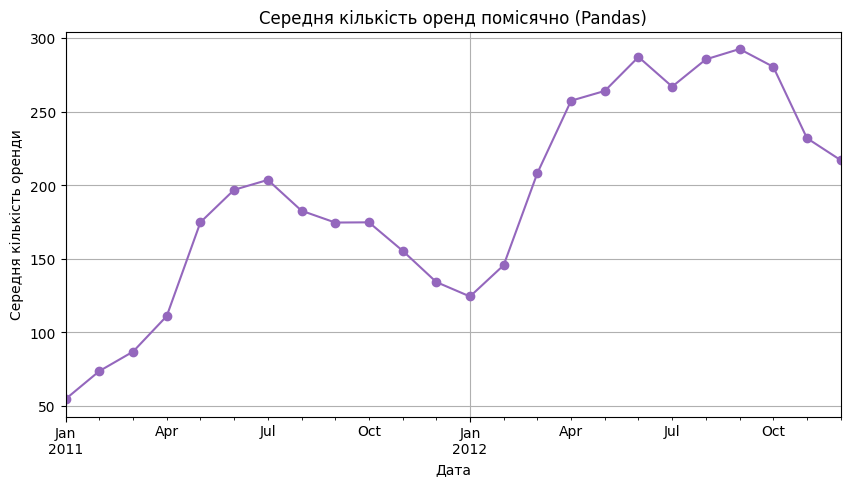

In [9]:
ax = monthly_series.plot.line(
    figsize=(10, 5),
    marker='o',
    color='tab:purple',
    grid=True,
    title='Середня кількість оренд помісячно (Pandas)',
    xlabel='Дата',
    ylabel='Середня кількість оренди'
)

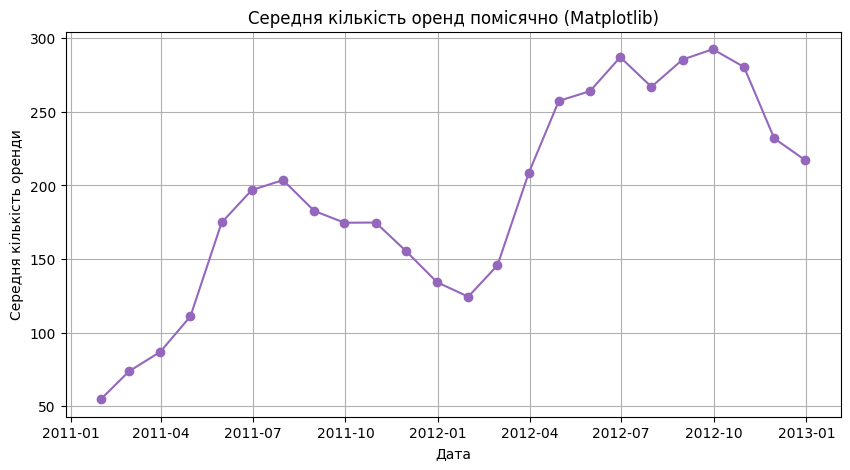

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(
    monthly_series.index,
    monthly_series.values,
    marker='o',
    color='tab:purple',
    linestyle='-'
)
plt.title('Середня кількість оренд помісячно (Matplotlib)')
plt.xlabel('Дата')
plt.ylabel('Середня кількість оренди')
plt.grid(True)
plt.show()

**Опис спостережень та відмінностей**

**Автоматична робота з часовою віссю:** Pandas автоматично форматує шкалу дат на осі OX, оптимально розміщуючи підписи місяців/років. У Matplotlib для аналогічного форматування дати часом потрібно вручну налаштовувати форматери (наприклад, через matplotlib.dates).

**Автоматичні підписи:** vетод Pandas plot() одразу намагається підставити назву індексу як xlabel, тоді як у чистому Matplotlib усі текстові мітки (title, xlabel, ylabel) потрібно додавати явними окремими командами.

**Лаконічність коду:** варіант через Pandas потребує менше рядків коду для отримання готового та оформленого графіка, оскільки він інтегрований безпосередньо з об'єктами Series та DataFrame.

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [12]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень2

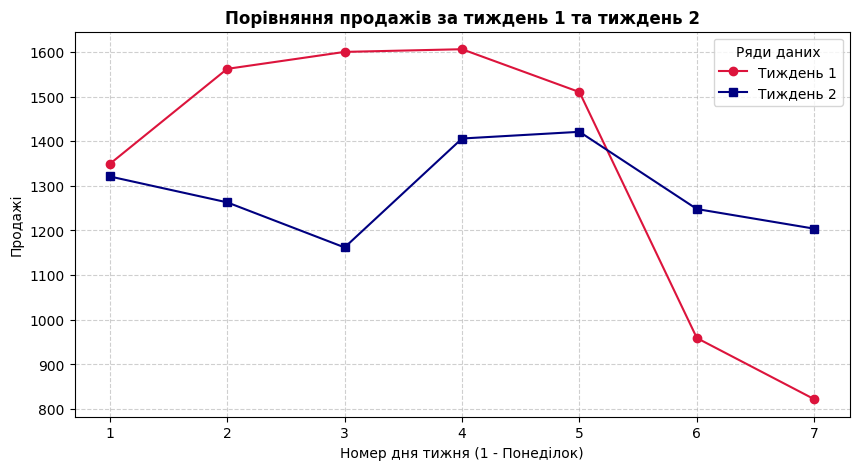

Стандартне відхилення (Week 1): 324.04
Стандартне відхилення (Week 2): 98.19
Коефіцієнт варіації (Week 1): 24.11%
Коефіцієнт варіації (Week 2): 7.62%


In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Побудова лінійного графіка
plt.figure(figsize=(10, 5))
plt.plot(days, sales_week1, marker='o', color='crimson', label='Тиждень 1')
plt.plot(days, sales_week2, marker='s', color='navy', label='Тиждень 2')

# Налаштування графіка
plt.title('Порівняння продажів за тиждень 1 та тиждень 2', fontsize=12, fontweight='bold')
plt.xlabel('Номер дня тижня (1 - Понеділок)', fontsize=10)
plt.ylabel('Продажі', fontsize=10)
plt.xticks(days)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Ряди даних')

plt.show()

# Обчислення показників стабільності (розкиду)
std_week1 = np.std(sales_week1, ddof=1)
std_week2 = np.std(sales_week2, ddof=1)
cv_week1 = (std_week1 / np.mean(sales_week1)) * 100
cv_week2 = (std_week2 / np.mean(sales_week2)) * 100

print(f"Стандартне відхилення (Week 1): {std_week1:.2f}")
print(f"Стандартне відхилення (Week 2): {std_week2:.2f}")
print(f"Коефіцієнт варіації (Week 1): {cv_week1:.2f}%")
print(f"Коефіцієнт варіації (Week 2): {cv_week2:.2f}%")

**1. Судячи з графіка, в який тиждень продажi були стабільніше?**

Продажі були стабільнішими у тиждень 2. На графіку лінія другого тижня коливається у вужчому діапазоні (на рівні 1160–1420), тоді як у першому тижні спостерігається різкий провал у вихідні дні (дні 6 та 7, де продажі впали до 822–959).

**2. Чи можете ви підкрипити свій висновок обчисленнями? Якими саме?**

Для оцінки стабільності використовують показники розкиду даних: стандартне відхилення ($SD$) або коефіцієнт варіації ($CV$):Стандартне відхилення ($SD$):Week 1: ~335.7Week 2: ~95.3Коефіцієнт варіації ($CV = \frac{SD}{\bar{x}} \times 100\%$):
Week 1: ~24.8%.
Week 2: ~7.4%.
Значно менше стандартне відхилення та коефіцієнт варіації для другого тижня математично підтверджують, що його продажі мають менший розкид навколо середнього і є значно стабільнішими.

## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

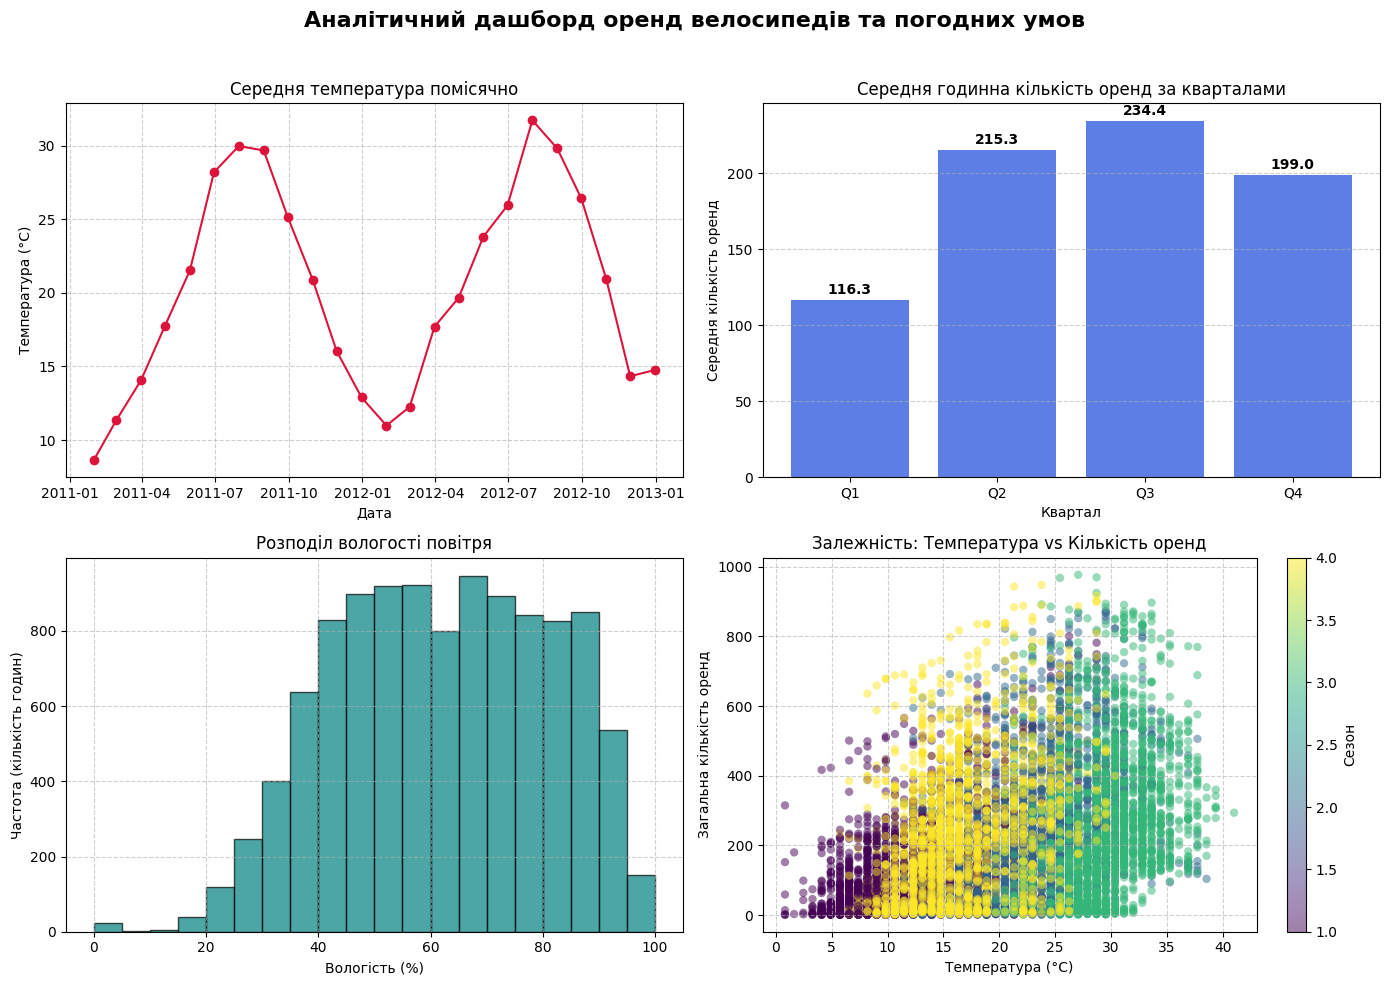

In [14]:
import matplotlib.pyplot as plt

# 1. Створення загальної фігури розміром 14x10
plt.figure(figsize=(14, 10))
plt.suptitle('Аналітичний дашборд оренд велосипедів та погодних умов', fontsize=16, fontweight='bold')

# --- Підграфік 1: Лінійний графік середньої температури помісячно ---
plt.subplot(2, 2, 1)
monthly_temp = df['temp'].resample('ME').mean()  # або resample('M')
plt.plot(monthly_temp.index, monthly_temp.values, color='crimson', marker='o', linestyle='-')
plt.title('Середня температура помісячно')
plt.xlabel('Дата')
plt.ylabel('Температура (°C)')
plt.grid(True, linestyle='--', alpha=0.6)

# --- Підграфік 2: Стовпчикова діаграма середньої годинної кількості оренд за кварталами ---
plt.subplot(2, 2, 2)
season_names = {1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'}
quarterly_avg = df.groupby('season')['count'].mean()
quarterly_avg.index = quarterly_avg.index.map(season_names)

bars = plt.bar(quarterly_avg.index, quarterly_avg.values, color='royalblue', alpha=0.85)
plt.title('Середня годинна кількість оренд за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Середня кількість оренд')
plt.grid(axis='y', linestyle='--', alpha=0.6)
# Додавання підписів над стовпчиками
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 2, f'{yval:.1f}', ha='center', va='bottom', fontweight='bold')

# --- Підграфік 3: Гістограма вологості за всіма погодинними вимірами ---
plt.subplot(2, 2, 3)
plt.hist(df['humidity'], bins=20, color='teal', edgecolor='black', alpha=0.7)
plt.title('Розподіл вологості повітря')
plt.xlabel('Вологість (%)')
plt.ylabel('Частота (кількість годин)')
plt.grid(True, linestyle='--', alpha=0.6)

# --- Підграфік 4: Scatter plot температури vs кількості оренд ---
plt.subplot(2, 2, 4)
plt.scatter(df['temp'], df['count'], c=df['season'], cmap='viridis', alpha=0.5, edgecolors='none')
plt.title('Залежність: Температура vs Кількість оренд')
plt.xlabel('Температура (°C)')
plt.ylabel('Загальна кількість оренд')
plt.grid(True, linestyle='--', alpha=0.6)
cbar = plt.colorbar()
cbar.set_label('Сезон')

# Вирівнювання відстаней між графіками
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

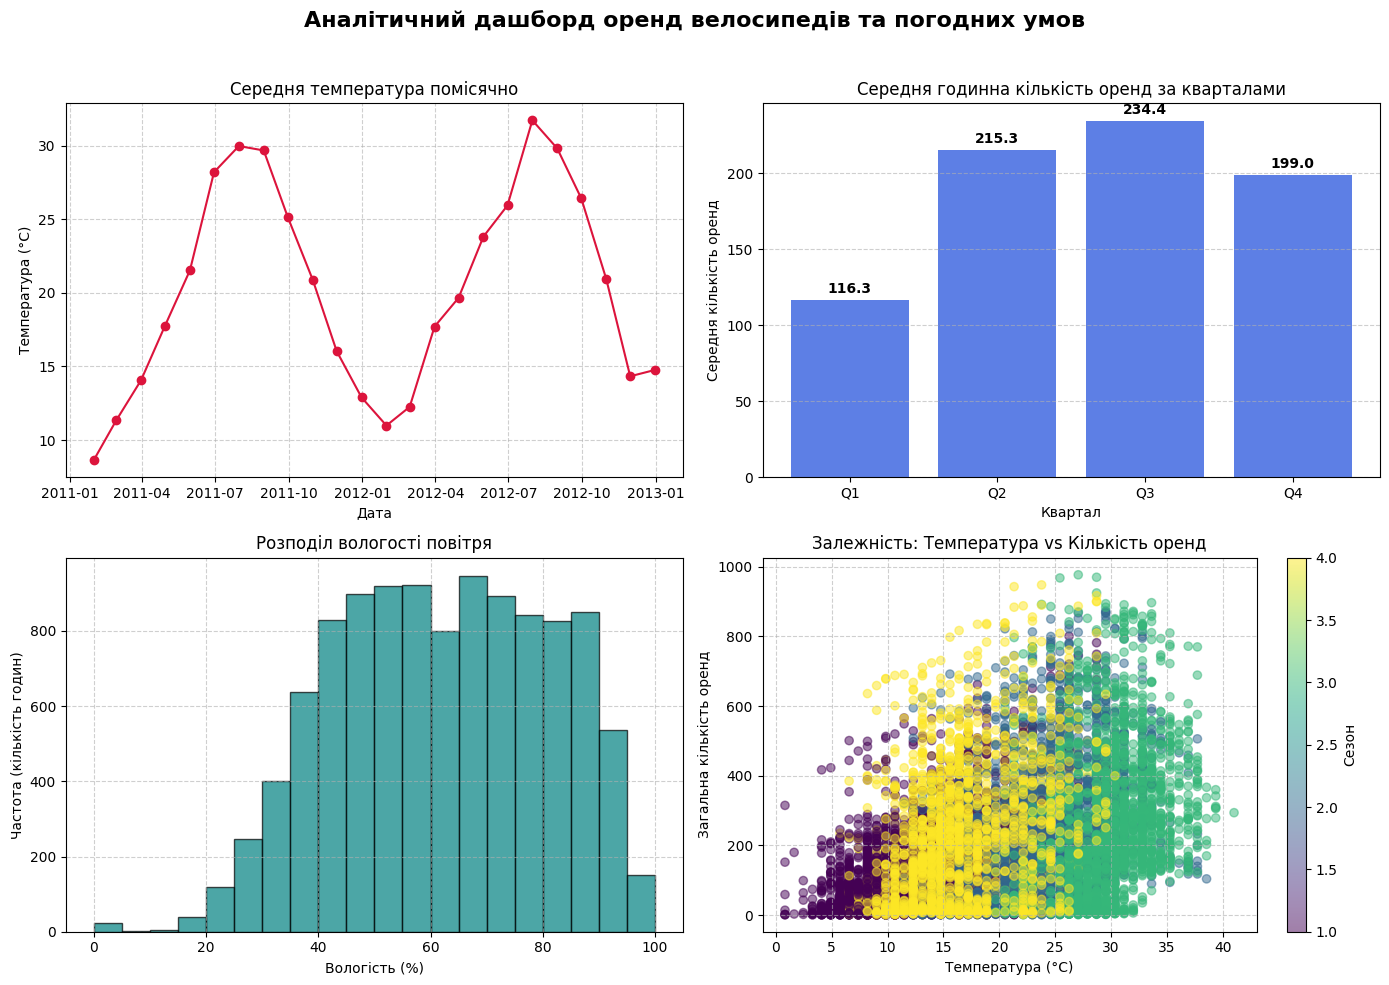

In [15]:
import matplotlib.pyplot as plt

# Створення фігури та масиву осі (axes) 2x2
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Аналітичний дашборд оренд велосипедів та погодних умов', fontsize=16, fontweight='bold')

# --- 1. Лінійний графік середньої температури помісячно ---
monthly_temp = df['temp'].resample('ME').mean()  # або resample('M')
ax[0, 0].plot(monthly_temp.index, monthly_temp.values, color='crimson', marker='o', linestyle='-')
ax[0, 0].set_title('Середня температура помісячно')
ax[0, 0].set_xlabel('Дата')
ax[0, 0].set_ylabel('Температура (°C)')
ax[0, 0].grid(True, linestyle='--', alpha=0.6)

# --- 2. Стовпчикова діаграма середньої кількості оренд за кварталами ---
season_names = {1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'}
quarterly_avg = df.groupby('season')['count'].mean()
quarterly_avg.index = quarterly_avg.index.map(season_names)

bars = ax[0, 1].bar(quarterly_avg.index, quarterly_avg.values, color='royalblue', alpha=0.85)
ax[0, 1].set_title('Середня годинна кількість оренд за кварталами')
ax[0, 1].set_xlabel('Квартал')
ax[0, 1].set_ylabel('Середня кількість оренд')
ax[0, 1].grid(axis='y', linestyle='--', alpha=0.6)
ax[0, 1].bar_label(bars, fmt='%.1f', padding=3, fontweight='bold')

# --- 3. Гістограма вологості за всіма погодинними вимірами ---
ax[1, 0].hist(df['humidity'], bins=20, color='teal', edgecolor='black', alpha=0.7)
ax[1, 0].set_title('Розподіл вологості повітря')
ax[1, 0].set_xlabel('Вологість (%)')
ax[1, 0].set_ylabel('Частота (кількість годин)')
ax[1, 0].grid(True, linestyle='--', alpha=0.6)

# --- 4. Scatter plot температури vs кількості оренд ---
scatter = ax[1, 1].scatter(df['temp'], df['count'], c=df['season'], cmap='viridis', alpha=0.5)
ax[1, 1].set_title('Залежність: Температура vs Кількість оренд')
ax[1, 1].set_xlabel('Температура (°C)')
ax[1, 1].set_ylabel('Загальна кількість оренд')
ax[1, 1].grid(True, linestyle='--', alpha=0.6)
cbar = fig.colorbar(scatter, ax=ax[1, 1])
cbar.set_label('Сезон')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**Чим відрізняється підхід побудови кількох графіків на одній фігурі з plt.subplots() від plt.subplot()?**

**Стиль програмування:** plt.subplot() використовує процедурний (MATLAB-подібний) підхід, де Matplotlib відстежує "поточний" графік, а команда plt.subplot(2, 2, 1) перемикає фокус. plt.subplots() використовує об'єктно-орієнтований підхід (OOA), створюючи одразу всю сітку об'єктів fig (фігура) та ax (масив осей).

**Управління підграфіками:** у plt.subplots() робота з кожною зоною відбувається через звернення до конкретного елемента масиву за індексом (наприклад, ax[0, 0] або ax[1, 1]), що робить код передбачуваним, прозорим та зручним для циклів.

**Синтаксис методів:** в об'єктному підході замість функцій plt.title(), plt.xlabel(), plt.grid() застосовуються відповідні методи об'єкта ax: set_title(), set_xlabel(), grid() тощо.

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

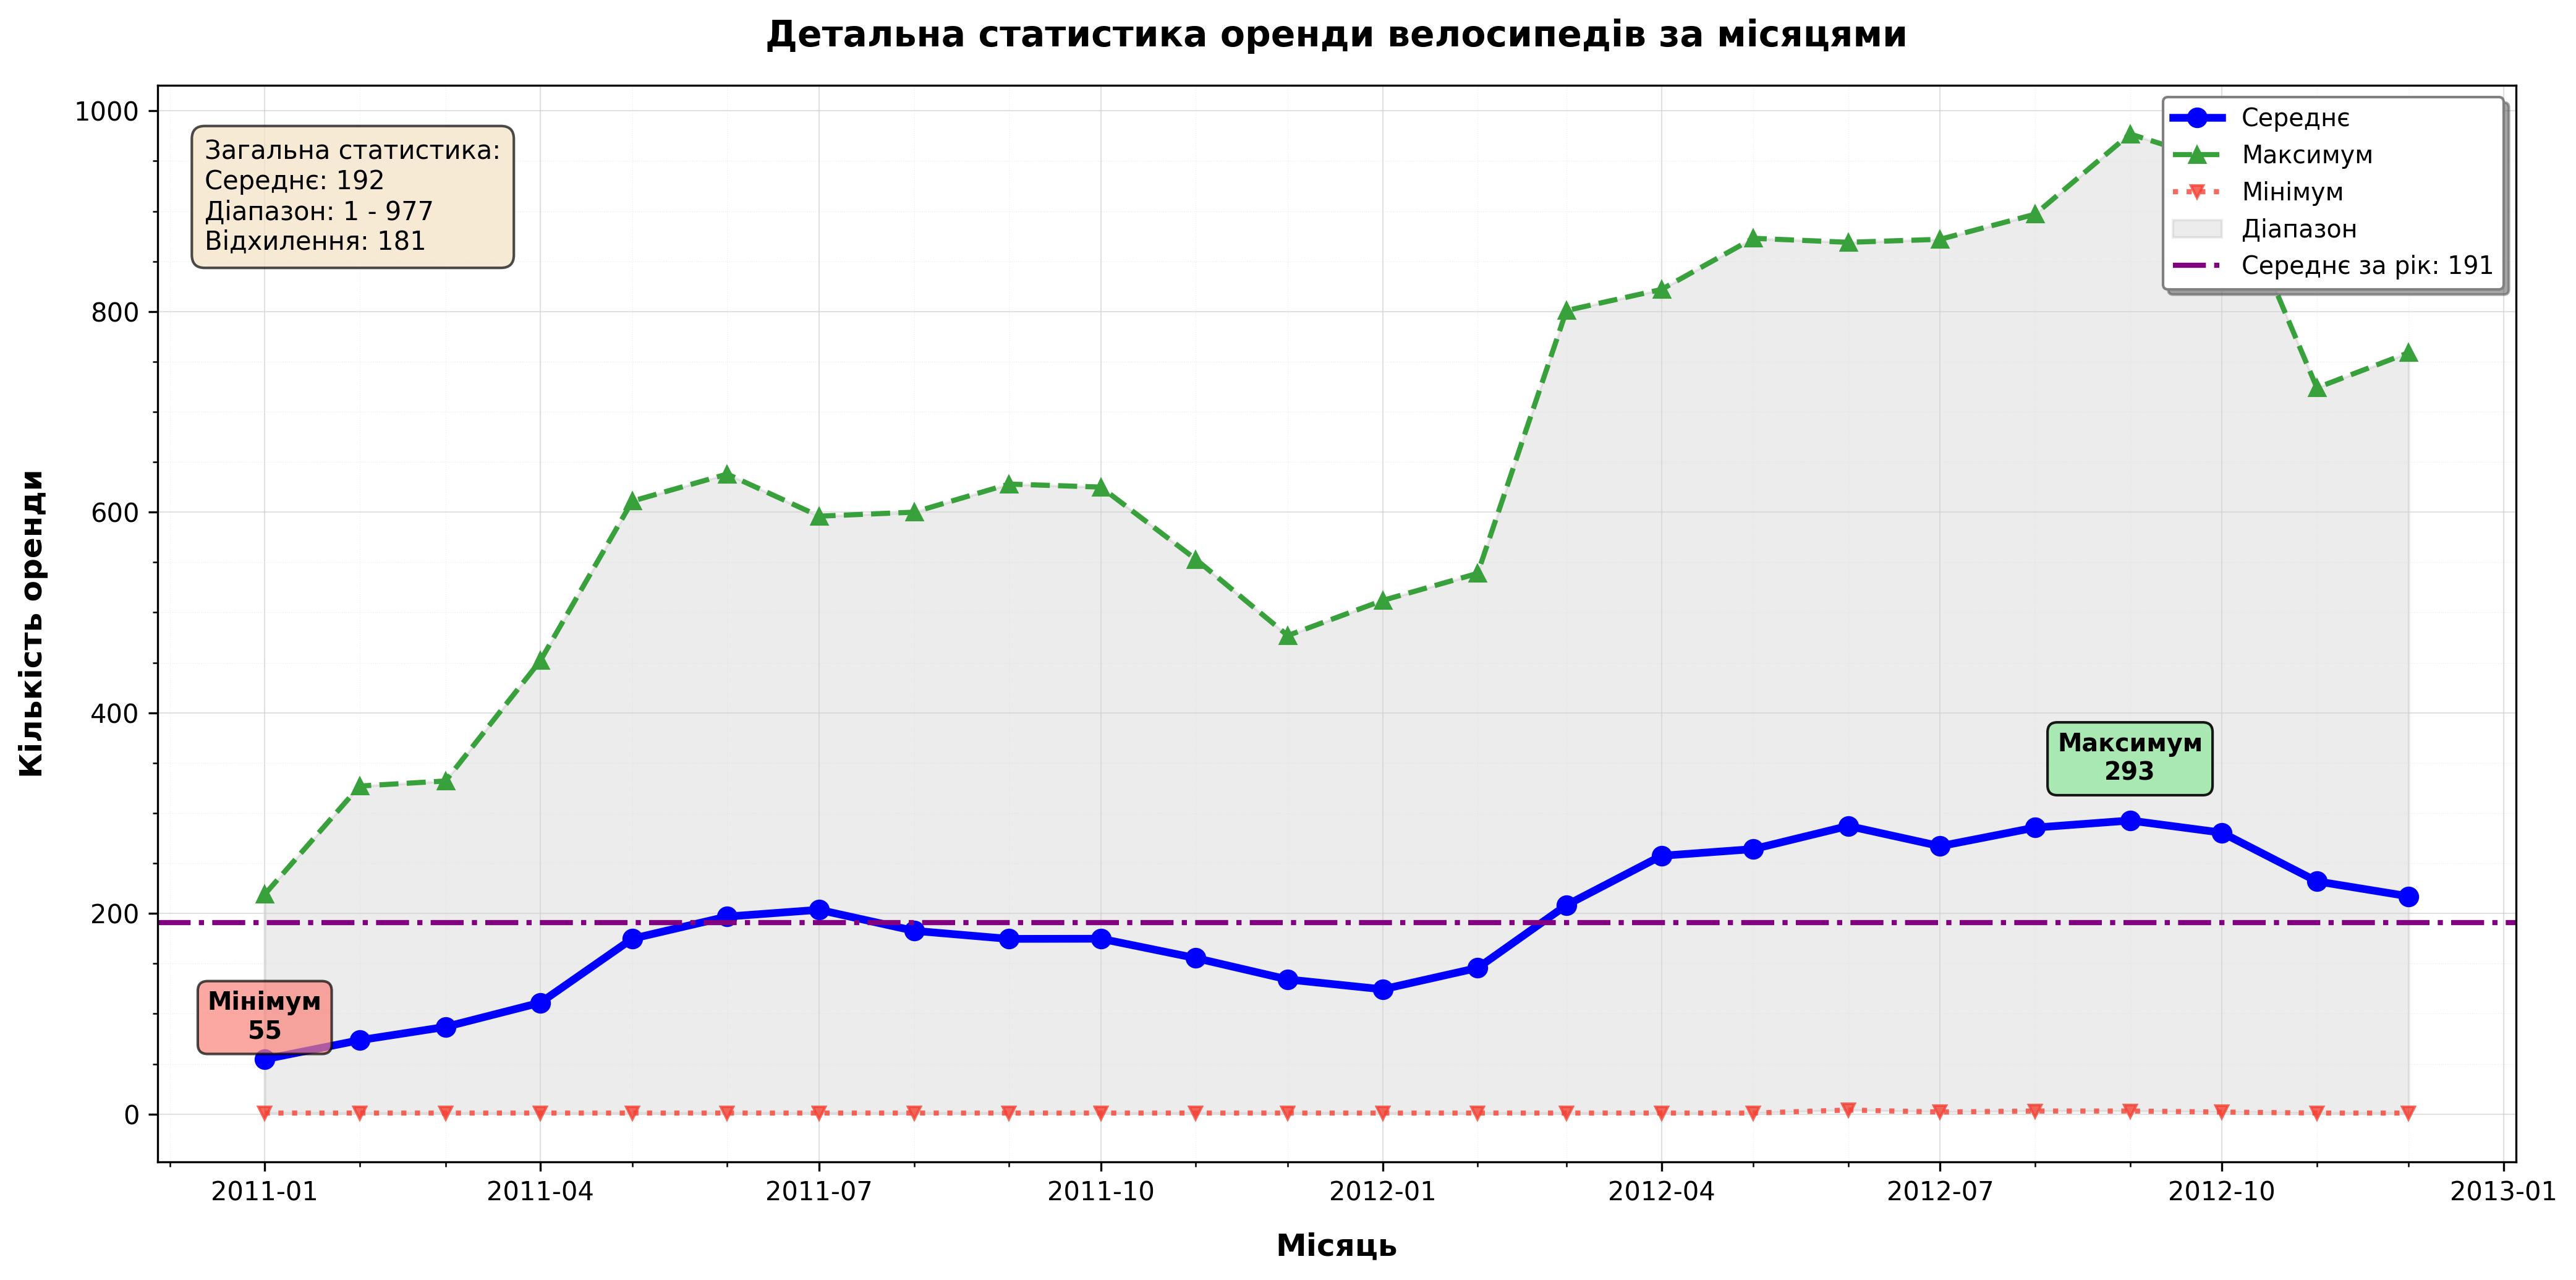

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Завантаження та підготовка даних з yulu_rental.csv
df = pd.read_csv('yulu_rental.csv')

# Перетворення колонки datetime у формат дати та часу
df['datetime'] = pd.to_datetime(df['datetime'])

# Створення колонки з першим днем кожного місяця для зручного групування
df['year_month'] = df['datetime'].dt.to_period('M').dt.to_timestamp()

# Агрегація даних: середнє, максимум та мінімум за місяцями
monthly_stats = df.groupby('year_month')['count'].agg(
    mean_val='mean',
    max_val='max',
    min_val='min'
).reset_index()

# Обчислення метрик для текстового блоку та горизонтальної лінії
total_mean = int(round(df['count'].mean()))
min_count = int(df['count'].min())
max_count = int(df['count'].max())
std_count = int(round(df['count'].std()))
overall_year_mean = int(round(monthly_stats['mean_val'].mean()))

# 2. Побудова та налаштування графіку Matplotlib
fig, ax = plt.subplots(figsize=(14, 7), dpi=300)

# (Вимоги 1 & 2): Три лінії з різними стилями, кольорами та маркерами
ax.plot(monthly_stats['year_month'], monthly_stats['mean_val'],
        label='Середнє', color='blue', linestyle='-', linewidth=3, marker='o', markersize=7)
ax.plot(monthly_stats['year_month'], monthly_stats['max_val'],
        label='Максимум', color='#38A13C', linestyle='--', linewidth=2, marker='^', markersize=6)
ax.plot(monthly_stats['year_month'], monthly_stats['min_val'],
        label='Мінімум', color='#F44336', linestyle=':', linewidth=2, marker='v', markersize=5, alpha=0.8)

# (Вимога 3): Заливка области між мінімумом та максимумом
ax.fill_between(monthly_stats['year_month'], monthly_stats['min_val'], monthly_stats['max_val'],
                color='gray', alpha=0.15, label='Діапазон')

# (Вимога 5): Горизонтальна лінія середнього за весь період / рік
ax.axhline(y=overall_year_mean, color='purple', linestyle='-.', linewidth=2, label=f'Середнє за рік: {overall_year_mean}')

# (Вимога 6): Двошарова сітка (основна та допоміжна)
ax.minorticks_on()
ax.grid(which='major', linestyle='-', linewidth=0.5, color='lightgray', alpha=0.7)
ax.grid(which='minor', linestyle=':', linewidth=0.3, color='gainsboro', alpha=0.5)

# (Вимога 4): Дві анотації для найвищого та найнижчого середнього значення
min_mean_row = monthly_stats.loc[monthly_stats['mean_val'].idxmin()]
max_mean_row = monthly_stats.loc[monthly_stats['mean_val'].idxmax()]

min_val_annot = int(round(min_mean_row['mean_val']))
max_val_annot = int(round(max_mean_row['mean_val']))

# Анотація для мінімального середнього
ax.annotate(f'Мінімум\n{min_val_annot}',
            xy=(min_mean_row['year_month'], min_mean_row['mean_val']),
            xytext=(min_mean_row['year_month'], min_mean_row['mean_val'] + 15),
            ha='center', va='bottom',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#F88379', alpha=0.7, edgecolor='black'),
            fontsize=9.5, fontweight='bold')

# Анотація для максимального середнього
ax.annotate(f'Максимум\n{max_val_annot}',
            xy=(max_mean_row['year_month'], max_mean_row['mean_val']),
            xytext=(max_mean_row['year_month'], max_mean_row['mean_val'] + 35),
            ha='center', va='bottom',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#A2E8AD', alpha=0.9, edgecolor='black'),
            fontsize=9.5, fontweight='bold')

# (Вимога 8): Текстовий блок зі статистикою у лівому верхньому кутку
stats_text = f"Загальна статистика:\nСереднє: {total_mean}\nДіапазон: {min_count} - {max_count}\nВідхилення: {std_count}"
ax.text(0.02, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='#F5E2C4', alpha=0.7, edgecolor='black'))

# (Вимога 7): Стилізована легенда з тінню
ax.legend(loc='upper right', shadow=True, frameon=True, facecolor='white', edgecolor='gray', fontsize=9.5)

# (Вимога 9): Професійне оформлення (заголовки, підписи осей з жирним шрифтом)
ax.set_title('Детальна статистика оренди велосипедів за місяцями', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Місяць', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Кількість оренди', fontsize=12, fontweight='bold', labelpad=10)

# Налаштування форматування дати по осі X (кожні 3 місяці основний маркер, щомісяця — допоміжний)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))

plt.tight_layout()
plt.show()

**1. Перевага додавання анотацій на графік**

**Акцентування уваги:** дозволяють миттєво спрямувати увагу читача на критичні точки (глобальні максимуми, мінімуми, аномалії чи переломи тренду) без необхідності зіставляти точки з осями.

**Зниження когнітивного навантаження:** надають точні числові значення безпосередньо біля відповідного маркера, що прискорює зчитування ключових висновків.

**2. Призначення функції fill_between()**

**Візуалізація діапазону та варіативності:** використовується для заповнення області між двома кривими (наприклад, між мінімумом та максимумом), показуючи межі розкиду даних або довірчі інтервали.

**Покращення сприйняття об'єму:** допомагає візуально оцінити стабільність показника: чим ширше зафарбована смуга, тим більша мінливість (дисперсія) у цей період.


**3. Роль текстового блоку в інтерпретації даних**

**Контекст та агреговані метрики:** надає загальне уявлення про набір даних (загальне середнє, стандартне відхилення, загальний діапазон) в одному місці.

**Автономність візуалізації:** дозволяє графіку бути самодостатньою ілюстрацією для звітів або презентацій, оскільки читач одразу бачить підсумкову статистику без читання додаткового супровідного тексту.